## Breathing tube prediction

- `Insertion of endotracheal tube`
- d_icd_procedures
    - icd9 code `9604`
    - 10,000 rows
- features:
    - Admission type
    - Admission location
    - diagnosis
    - Age
    - Gender
    - Insurance

    - Recent admissions (number? specific diagnoses? Admission in last year? time spent for visit)
    - Recent Prescriptions
    - First care unit


In [ ]:
# Colab link: https://colab.research.google.com/drive/1a_6y3zqcrMkz43ceWAVmn5o7juf3_wau?usp=sharing

import pandas as pd

DATA_PATH = '/Users/owenmccormack/Desktop/Grad_School_Projects/Spring_2025/AI_In_Healthcare/Assignments/MIMIC_ML_DL/data'

In [201]:
# utility function for later
def one_hot_encode(df, column_name):
    one_hot = pd.get_dummies(df[column_name])
    df = df.drop(column_name, axis = 1)
    one_hot.columns = [f"{column_name}_{col}" for col in one_hot.columns]
    df = df.join(one_hot)
    return df

## Step 1 - Gathering the data (prior to cleaning)
- Get admission, patient, and procedure data

In [202]:
admissions_df = pd.read_csv(f'{DATA_PATH}/ADMISSIONS.csv.gz')
patients_df = pd.read_csv(f'{DATA_PATH}/PATIENTS.csv.gz')
procedures_df = pd.read_csv(f'{DATA_PATH}/PROCEDURES_ICD.csv.gz')
d_icd_procedures_df = pd.read_csv(f'{DATA_PATH}/D_ICD_PROCEDURES.csv.gz')

## Step 2 Cleaning and Feature Engineering
- Create use chosen features to narrow down table
- Rename columns as needed 

### Admissions specific features
- diagnosis
- insurance
- admission_type
- admission_location
- admission time (for age calculation)
- ethnicity
- subject_id, hadm_id (for merging)

In [203]:
merged_df = admissions_df
merged_df = merged_df[['SUBJECT_ID', 'HADM_ID', 'DIAGNOSIS', 'INSURANCE', 'ADMISSION_TYPE', 'ADMISSION_LOCATION', 'ADMITTIME', 'ETHNICITY']]
merged_df['ADMITTIME'] = pd.to_datetime(merged_df['ADMITTIME'])

/var/folders/50/ps11njl93r52n622qd1nd_h80000gn/T/ipykernel_57031/3746783806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df['ADMITTIME'] = pd.to_datetime(merged_df['ADMITTIME'])


In [204]:
merged_df.head()

,SUBJECT_ID,HADM_ID,DIAGNOSIS,INSURANCE,ADMISSION_TYPE,ADMISSION_LOCATION,ADMITTIME,ETHNICITY
0,22,165315,BENZODIAZEPINE OVERDOSE,Private,EMERGENCY,EMERGENCY ROOM ADMIT,2196-04-09 12:26:00,WHITE
1,23,152223,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,Medicare,ELECTIVE,PHYS REFERRAL/NORMAL DELI,2153-09-03 07:15:00,WHITE
2,23,124321,BRAIN MASS,Medicare,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,2157-10-18 19:34:00,WHITE
3,24,161859,INTERIOR MYOCARDIAL INFARCTION,Private,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,2139-06-06 16:14:00,WHITE
4,25,129635,ACUTE CORONARY SYNDROME,Private,EMERGENCY,EMERGENCY ROOM ADMIT,2160-11-02 02:06:00,WHITE


### Patients specific features
- DOB (for age calculation)
- gender

In [205]:
merged_df = merged_df.merge(patients_df[['SUBJECT_ID', 'GENDER', 'DOB']], on='SUBJECT_ID', how='inner')
merged_df['DOB'] = pd.to_datetime(merged_df['DOB'])

In [206]:
merged_df.head()

,SUBJECT_ID,HADM_ID,DIAGNOSIS,INSURANCE,ADMISSION_TYPE,ADMISSION_LOCATION,ADMITTIME,ETHNICITY,GENDER,DOB
0,22,165315,BENZODIAZEPINE OVERDOSE,Private,EMERGENCY,EMERGENCY ROOM ADMIT,2196-04-09 12:26:00,WHITE,F,2131-05-07
1,23,152223,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,Medicare,ELECTIVE,PHYS REFERRAL/NORMAL DELI,2153-09-03 07:15:00,WHITE,M,2082-07-17
2,23,124321,BRAIN MASS,Medicare,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,2157-10-18 19:34:00,WHITE,M,2082-07-17
3,24,161859,INTERIOR MYOCARDIAL INFARCTION,Private,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,2139-06-06 16:14:00,WHITE,M,2100-05-31
4,25,129635,ACUTE CORONARY SYNDROME,Private,EMERGENCY,EMERGENCY ROOM ADMIT,2160-11-02 02:06:00,WHITE,M,2101-11-21


### Procedures specific features
- breathing_tube_inserted (calculated based off of icd code `96.04`)

In [207]:
admissions_with_9604 = procedures_df[['ICD9_CODE','HADM_ID']]
admissions_with_9604 = admissions_with_9604[admissions_with_9604['ICD9_CODE'] == 9604]
admissions_with_9604 = admissions_with_9604['HADM_ID'].unique()

df_admissions_with_9604 = pd.DataFrame(admissions_with_9604, columns=['HADM_ID'])
merged_df['breathing_tube_inserted'] = merged_df['HADM_ID'].isin(admissions_with_9604)
len(admissions_with_9604)

9882

In [208]:
merged_df.head()

,SUBJECT_ID,HADM_ID,DIAGNOSIS,INSURANCE,ADMISSION_TYPE,ADMISSION_LOCATION,ADMITTIME,ETHNICITY,GENDER,DOB,breathing_tube_inserted
0,22,165315,BENZODIAZEPINE OVERDOSE,Private,EMERGENCY,EMERGENCY ROOM ADMIT,2196-04-09 12:26:00,WHITE,F,2131-05-07,True
1,23,152223,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,Medicare,ELECTIVE,PHYS REFERRAL/NORMAL DELI,2153-09-03 07:15:00,WHITE,M,2082-07-17,False
2,23,124321,BRAIN MASS,Medicare,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,2157-10-18 19:34:00,WHITE,M,2082-07-17,False
3,24,161859,INTERIOR MYOCARDIAL INFARCTION,Private,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,2139-06-06 16:14:00,WHITE,M,2100-05-31,False
4,25,129635,ACUTE CORONARY SYNDROME,Private,EMERGENCY,EMERGENCY ROOM ADMIT,2160-11-02 02:06:00,WHITE,M,2101-11-21,False


### Adding One hot encoding to categorical columns

In [209]:
merged_df.columns

Index(['SUBJECT_ID', 'HADM_ID', 'DIAGNOSIS', 'INSURANCE', 'ADMISSION_TYPE',
       'ADMISSION_LOCATION', 'ADMITTIME', 'ETHNICITY', 'GENDER', 'DOB',
       'breathing_tube_inserted'],
      dtype='object')

In [210]:
# one hot encoding
merged_df = one_hot_encode(merged_df, 'INSURANCE')
merged_df = one_hot_encode(merged_df, 'ADMISSION_TYPE')
merged_df = one_hot_encode(merged_df, 'ADMISSION_LOCATION')
merged_df = one_hot_encode(merged_df, 'ETHNICITY')


In [211]:
merged_df.columns

Index(['SUBJECT_ID', 'HADM_ID', 'DIAGNOSIS', 'ADMITTIME', 'GENDER', 'DOB',
       'breathing_tube_inserted', 'INSURANCE_Government', 'INSURANCE_Medicaid',
       'INSURANCE_Medicare', 'INSURANCE_Private', 'INSURANCE_Self Pay',
       'ADMISSION_TYPE_ELECTIVE', 'ADMISSION_TYPE_EMERGENCY',
       'ADMISSION_TYPE_NEWBORN', 'ADMISSION_TYPE_URGENT',
       'ADMISSION_LOCATION_** INFO NOT AVAILABLE **',
       'ADMISSION_LOCATION_CLINIC REFERRAL/PREMATURE',
       'ADMISSION_LOCATION_EMERGENCY ROOM ADMIT',
       'ADMISSION_LOCATION_HMO REFERRAL/SICK',
       'ADMISSION_LOCATION_PHYS REFERRAL/NORMAL DELI',
       'ADMISSION_LOCATION_TRANSFER FROM HOSP/EXTRAM',
       'ADMISSION_LOCATION_TRANSFER FROM OTHER HEALT',
       'ADMISSION_LOCATION_TRANSFER FROM SKILLED NUR',
       'ADMISSION_LOCATION_TRSF WITHIN THIS FACILITY',
       'ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE',
       'ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE FEDERALLY RECOGNIZED TRIBE',
       'ETHNICITY_ASIAN', 'ETHNICITY_ASIAN - 

### Additional Feature Cleanup and Engineering
- columns lowercased for uniformity
- `age` column added
- `respiratory_diagnosis` column added to indicated presence of respiratory-related diagnosis
- Additional columns added relating to specific diagnosis, age thresholds, and other combinations
- Ethnicity columns grouped and simplified

In [212]:
features = merged_df[['GENDER']].rename(columns={'GENDER': 'gender'})
features['gender'] = features['gender'].map({'M': 1, 'F': 0})

# lowercase insurance column names for consistency
features['insurance_government'] = merged_df['INSURANCE_Government']
features['insurance_medicaid'] = merged_df['INSURANCE_Medicaid']
features['insurance_medicare'] = merged_df['INSURANCE_Medicare']
features['insurance_private'] = merged_df['INSURANCE_Private']
features['insurance_self_pay'] = merged_df['INSURANCE_Self Pay']

# lowercase admission type column names for consistency
features['admission_type_elective'] = merged_df['ADMISSION_TYPE_ELECTIVE']
features['admission_type_emergency'] = merged_df['ADMISSION_TYPE_EMERGENCY']
features['admission_type_newborn'] = merged_df['ADMISSION_TYPE_NEWBORN']
features['admission_type_urgent'] = merged_df['ADMISSION_TYPE_URGENT']

# lowercase admission location column names for consistency
features['admission_location_no_info'] = merged_df['ADMISSION_LOCATION_** INFO NOT AVAILABLE **']
features['admission_location_clinic_referral'] = merged_df['ADMISSION_LOCATION_CLINIC REFERRAL/PREMATURE']
features['admission_location_emergency_room'] = merged_df['ADMISSION_LOCATION_EMERGENCY ROOM ADMIT']
features['admission_location_hmo_referral'] = merged_df['ADMISSION_LOCATION_HMO REFERRAL/SICK']
features['admission_location_phys_referral'] = merged_df['ADMISSION_LOCATION_PHYS REFERRAL/NORMAL DELI']
features['admission_location_trans_from_hosp'] = merged_df['ADMISSION_LOCATION_TRANSFER FROM HOSP/EXTRAM']
features['admission_location_trans_from_other'] = merged_df['ADMISSION_LOCATION_TRANSFER FROM OTHER HEALT']
features['admission_location_trans_from_snf'] = merged_df['ADMISSION_LOCATION_TRANSFER FROM SKILLED NUR']
features['admission_location_trans_from_within'] = merged_df['ADMISSION_LOCATION_TRSF WITHIN THIS FACILITY']

# add calculated age feature
features['age'] = merged_df['ADMITTIME'].dt.year - merged_df['DOB'].dt.year

# Add respiratory diagnosis feature
resp_substrings = ['RESPIRATORY', 'PNEUMONIA', 'BRONCH', 'ASTHMA', 'COUGH', 'COPD', 'EMPHYSEMA', 'PULMONARY']
resp_substrings = '|'.join(resp_substrings)
features['respiratory_diagnosis'] = merged_df['DIAGNOSIS'].str.contains(resp_substrings, case=False, na=False).astype(int)

# Add target feature for breathing tube insertion
features['breathing_tube_inserted'] = merged_df['breathing_tube_inserted']

In [213]:
# Add additional diagnosis features for specific respiratory conditions
specific_resp_conditions = {
    'pneumonia': ['PNEUMONIA', 'PNEUMONITIS'],
    'copd': ['COPD', 'EMPHYSEMA', 'CHRONIC OBSTRUCTIVE'],
    'asthma': ['ASTHMA'],
    'respiratory_failure': ['RESPIRATORY FAILURE', 'RESP FAILURE'],
    'pulmonary_edema': ['PULMONARY EDEMA', 'FLUID OVERLOAD'],
    'ards': ['ARDS', 'ACUTE RESPIRATORY DISTRESS']
}
for condition, keywords in specific_resp_conditions.items():
    pattern = '|'.join(keywords)
    features[f'diagnosis_{condition}'] = merged_df['DIAGNOSIS'].str.contains(pattern, case=False, na=False).astype(int)

# Add Age-related threshold features 
features['age_over_65'] = (features['age'] > 65).astype(int)
features['age_over_80'] = (features['age'] > 80).astype(int)
features['age_under_18'] = (features['age'] < 18).astype(int)

# Add Combinations that might be clinically relevant
features['emergency_resp_diagnosis'] = features['admission_type_emergency'] * features['respiratory_diagnosis']
features['elderly_emergency'] = features['age_over_65'] * features['admission_type_emergency']
features['elderly_resp_diagnosis'] = features['age_over_65'] * features['respiratory_diagnosis']

# Add ethnicity features
ethnicity_cols = [col for col in merged_df.columns if 'ETHNICITY' in col]
features['ethnicity_white'] = merged_df[[col for col in ethnicity_cols if 'WHITE' in col]].max(axis=1)
features['ethnicity_black'] = merged_df[[col for col in ethnicity_cols if 'BLACK' in col]].max(axis=1)
features['ethnicity_hispanic'] = merged_df[[col for col in ethnicity_cols if 'HISPANIC' in col]].max(axis=1)
features['ethnicity_asian'] = merged_df[[col for col in ethnicity_cols if 'ASIAN' in col]].max(axis=1)

# Add cardiac-related diagnosis features in case they are relevant
cardiac_keywords = ['HEART FAIL', 'CARDIAC', 'MYOCARDIAL', 'CORONARY', 'ATRIAL FIB', 'AFIB']
cardiac_pattern = '|'.join(cardiac_keywords)
features['cardiac_diagnosis'] = merged_df['DIAGNOSIS'].str.contains(cardiac_pattern, case=False, na=False).astype(int)

# Add severe illness diagnosis features in case they are relevant
icu_keywords = ['SEPSIS', 'SEPTIC', 'SHOCK', 'MULTI-ORGAN', 'MULTIORGAN', 'FAILURE']
icu_pattern = '|'.join(icu_keywords)
features['severe_illness_diagnosis'] = merged_df['DIAGNOSIS'].str.contains(icu_pattern, case=False, na=False).astype(int)

In [214]:
# final set of features
features.columns

Index(['gender', 'insurance_government', 'insurance_medicaid',
       'insurance_medicare', 'insurance_private', 'insurance_self_pay',
       'admission_type_elective', 'admission_type_emergency',
       'admission_type_newborn', 'admission_type_urgent',
       'admission_location_no_info', 'admission_location_clinic_referral',
       'admission_location_emergency_room', 'admission_location_hmo_referral',
       'admission_location_phys_referral',
       'admission_location_trans_from_hosp',
       'admission_location_trans_from_other',
       'admission_location_trans_from_snf',
       'admission_location_trans_from_within', 'age', 'respiratory_diagnosis',
       'breathing_tube_inserted', 'diagnosis_pneumonia', 'diagnosis_copd',
       'diagnosis_asthma', 'diagnosis_respiratory_failure',
       'diagnosis_pulmonary_edema', 'diagnosis_ards', 'age_over_65',
       'age_over_80', 'age_under_18', 'emergency_resp_diagnosis',
       'elderly_emergency', 'elderly_resp_diagnosis', 'ethnicity

In [215]:
# Feature correlations with target
correlation_with_target = features.corr()['breathing_tube_inserted'].sort_values(ascending=False)
print("Top correlations with target:")
print(correlation_with_target.head(10))
print("\nBottom correlations with target:")
print(correlation_with_target.tail(10))

print("Original class distribution:")
print(merged_df['breathing_tube_inserted'].value_counts())
print(f"Imbalance ratio: 1:{merged_df['breathing_tube_inserted'].value_counts()[0]/merged_df['breathing_tube_inserted'].value_counts()[1]:.2f}")

Top correlations with target:
breathing_tube_inserted              1.000000
admission_location_emergency_room    0.109713
admission_type_emergency             0.079779
emergency_resp_diagnosis             0.076048
respiratory_diagnosis                0.074330
diagnosis_respiratory_failure        0.062835
severe_illness_diagnosis             0.057652
elderly_resp_diagnosis               0.052472
diagnosis_pneumonia                  0.051422
elderly_emergency                    0.030783
Name: breathing_tube_inserted, dtype: float64

Bottom correlations with target:
ethnicity_white                      -0.008170
admission_location_trans_from_hosp   -0.011385
admission_location_no_info           -0.012513
admission_type_newborn               -0.012892
age_under_18                         -0.014533
ethnicity_asian                      -0.020106
insurance_private                    -0.032487
cardiac_diagnosis                    -0.060154
admission_type_elective              -0.092438
admissi

/var/folders/50/ps11njl93r52n622qd1nd_h80000gn/T/ipykernel_57031/4081481550.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Imbalance ratio: 1:{merged_df['breathing_tube_inserted'].value_counts()[0]/merged_df['breathing_tube_inserted'].value_counts()[1]:.2f}")


## Step 3 - Setup model and training
- Split cleaned data into train/test/validation
- Initialize multiple different AI approaches (decision tree, gradient booting, etc)

In [216]:
from sklearn.model_selection import train_test_split

# Assuming merged_df is your DataFrame and 'target_column' is your target variable
y = features['breathing_tube_inserted']
X = features.drop(columns=['breathing_tube_inserted'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [217]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

# Check class distribution
print("Original class distribution:")
print(y_train.value_counts())
print(f"Imbalance ratio: 1:{y_train.value_counts()[0]/y_train.value_counts()[1]:.2f}")

# Approach 1: SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Approach 2: ADASYN (Adaptive Synthetic Sampling)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Approach 3: Random Under-Sampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Approach 4: SMOTEENN (SMOTE + Edited Nearest Neighbors)
smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)

# Approach 5: SMOTETomek (SMOTE + Tomek links)
smotetomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_train, y_train)

# Check new distributions
sampling_techniques = {
    'Original': (X_train, y_train),
    'SMOTE': (X_train_smote, y_train_smote),
    'ADASYN': (X_train_adasyn, y_train_adasyn),
    'Random Under-Sampling': (X_train_rus, y_train_rus),
    'SMOTEENN': (X_train_smoteenn, y_train_smoteenn),
    'SMOTETomek': (X_train_smotetomek, y_train_smotetomek)
}

for name, (X, y) in sampling_techniques.items():
    print(f"\n{name} class distribution:")
    print(y.value_counts())
    ratio = y.value_counts()[0]/y.value_counts()[1] if 1 in y.value_counts() and 0 in y.value_counts() else 0
    print(f"Imbalance ratio: 1:{ratio:.2f}")

Original class distribution:
breathing_tube_inserted
False    39275
True      7905
Name: count, dtype: int64
Imbalance ratio: 1:4.97


/var/folders/50/ps11njl93r52n622qd1nd_h80000gn/T/ipykernel_57031/3228769024.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Imbalance ratio: 1:{y_train.value_counts()[0]/y_train.value_counts()[1]:.2f}")



Original class distribution:
breathing_tube_inserted
False    39275
True      7905
Name: count, dtype: int64
Imbalance ratio: 1:0.00

SMOTE class distribution:
breathing_tube_inserted
False    39275
True     39275
Name: count, dtype: int64
Imbalance ratio: 1:0.00

ADASYN class distribution:
breathing_tube_inserted
False    39275
True     37210
Name: count, dtype: int64
Imbalance ratio: 1:0.00

Random Under-Sampling class distribution:
breathing_tube_inserted
False    7905
True     7905
Name: count, dtype: int64
Imbalance ratio: 1:0.00

SMOTEENN class distribution:
breathing_tube_inserted
True     15302
False    13698
Name: count, dtype: int64
Imbalance ratio: 1:0.00

SMOTETomek class distribution:
breathing_tube_inserted
False    39119
True     39119
Name: count, dtype: int64
Imbalance ratio: 1:0.00


In [218]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

MAX_ITER = 1000
N_ESTIMATORS = 100

models = [
    SGDClassifier(random_state=0, max_iter=MAX_ITER),
    LogisticRegression(random_state=0, max_iter=MAX_ITER),
    GradientBoostingClassifier(random_state=0, n_estimators=N_ESTIMATORS),
    RandomForestClassifier(random_state=0, n_estimators=N_ESTIMATORS),
    KNeighborsClassifier()
]

# Dictionary to store results for all sampling techniques
all_sampling_results = {}

# Loop through all sampling techniques
for sampling_name, (X_train_sampled, y_train_sampled) in sampling_techniques.items():
    print(f"\nEvaluating models with {sampling_name} sampling technique:")
    
    # Results dictionary for this sampling technique
    sampling_results = {}
    
    for model in models:
        classifier = model
        
        # Use the appropriate training data
        train_features = X_train_sampled
        test_features = X_test
        
        # Apply scaling if needed
        if isinstance(model, (SGDClassifier, LogisticRegression)):
            scaler = StandardScaler()
            train_features = scaler.fit_transform(train_features)
            test_features = scaler.transform(test_features)
            classifier.fit(train_features, y_train_sampled)
        else:
            classifier.fit(train_features, y_train_sampled)
        
        # Get predictions
        if hasattr(classifier, 'predict_proba'):
            y_test_preds = classifier.predict_proba(test_features)[:, 1]
        else:
            y_test_preds = classifier.decision_function(test_features)
        
        # Get model name
        name = str(model).split("(")[0]
        
        # Calculate ROC-AUC
        roc_auc = roc_auc_score(y_test, y_test_preds)
        
        # Store result
        sampling_results[name] = roc_auc
        print(f"  {name}: ROC-AUC = {roc_auc:.4f}")
    
    # Store results for this sampling technique
    all_sampling_results[sampling_name] = sampling_results

# Find the best model and sampling technique combination
best_roc = 0
best_model = ""
best_sampling = ""

for sampling, results in all_sampling_results.items():
    for model, score in results.items():
        if score > best_roc:
            best_roc = score
            best_model = model
            best_sampling = sampling

print(f"\nBest combination: {best_model} with {best_sampling} sampling (ROC-AUC: {best_roc:.4f})")

# Print all results in a tabular format
print("\nAll results:")
for sampling, results in all_sampling_results.items():
    print(f"\n{sampling} sampling:")
    for model, score in results.items():
        print(f"  {model}: {score:.4f}")


Evaluating models with Original sampling technique:
  SGDClassifier: ROC-AUC = 0.5593
  LogisticRegression: ROC-AUC = 0.6366
  GradientBoostingClassifier: ROC-AUC = 0.6444
  RandomForestClassifier: ROC-AUC = 0.5839
  KNeighborsClassifier: ROC-AUC = 0.5492

Evaluating models with SMOTE sampling technique:
  SGDClassifier: ROC-AUC = 0.6032
  LogisticRegression: ROC-AUC = 0.6080
  GradientBoostingClassifier: ROC-AUC = 0.6238
  RandomForestClassifier: ROC-AUC = 0.5727
  KNeighborsClassifier: ROC-AUC = 0.5648

Evaluating models with ADASYN sampling technique:
  SGDClassifier: ROC-AUC = 0.5995
  LogisticRegression: ROC-AUC = 0.6019
  GradientBoostingClassifier: ROC-AUC = 0.6168
  RandomForestClassifier: ROC-AUC = 0.5730
  KNeighborsClassifier: ROC-AUC = 0.5576

Evaluating models with Random Under-Sampling sampling technique:
  SGDClassifier: ROC-AUC = 0.5998
  LogisticRegression: ROC-AUC = 0.6367
  GradientBoostingClassifier: ROC-AUC = 0.6432
  RandomForestClassifier: ROC-AUC = 0.5899
  KNe

In [219]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Convert the all_sampling_results dictionary to a DataFrame for easier plotting
results_df = []
for sampling_name, sampling_results in all_sampling_results.items():
    for model_name, score in sampling_results.items():
        results_df.append({
            'Sampling Technique': sampling_name,
            'Model': model_name,
            'ROC-AUC': score
        })
results_df = pd.DataFrame(results_df)

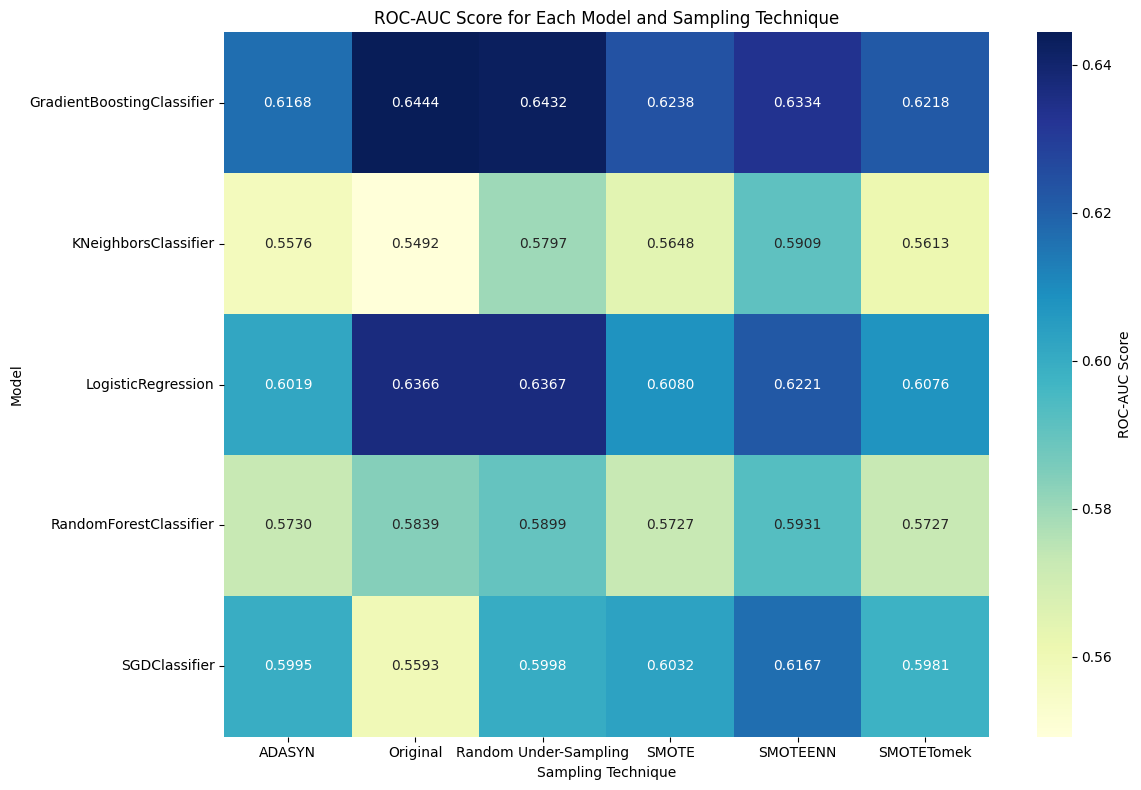

In [ ]:
# Create a heatmap for a visual comparison
plt.figure(figsize=(12, 8))
heatmap_data = results_df.pivot(index='Model', columns='Sampling Technique', values='ROC-AUC')
heatmap = sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.4f', cbar_kws={'label': 'ROC-AUC Score'})
plt.title('ROC-AUC Score for Each Model and Sampling Technique')
plt.tight_layout()
plt.savefig('model_sampling_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


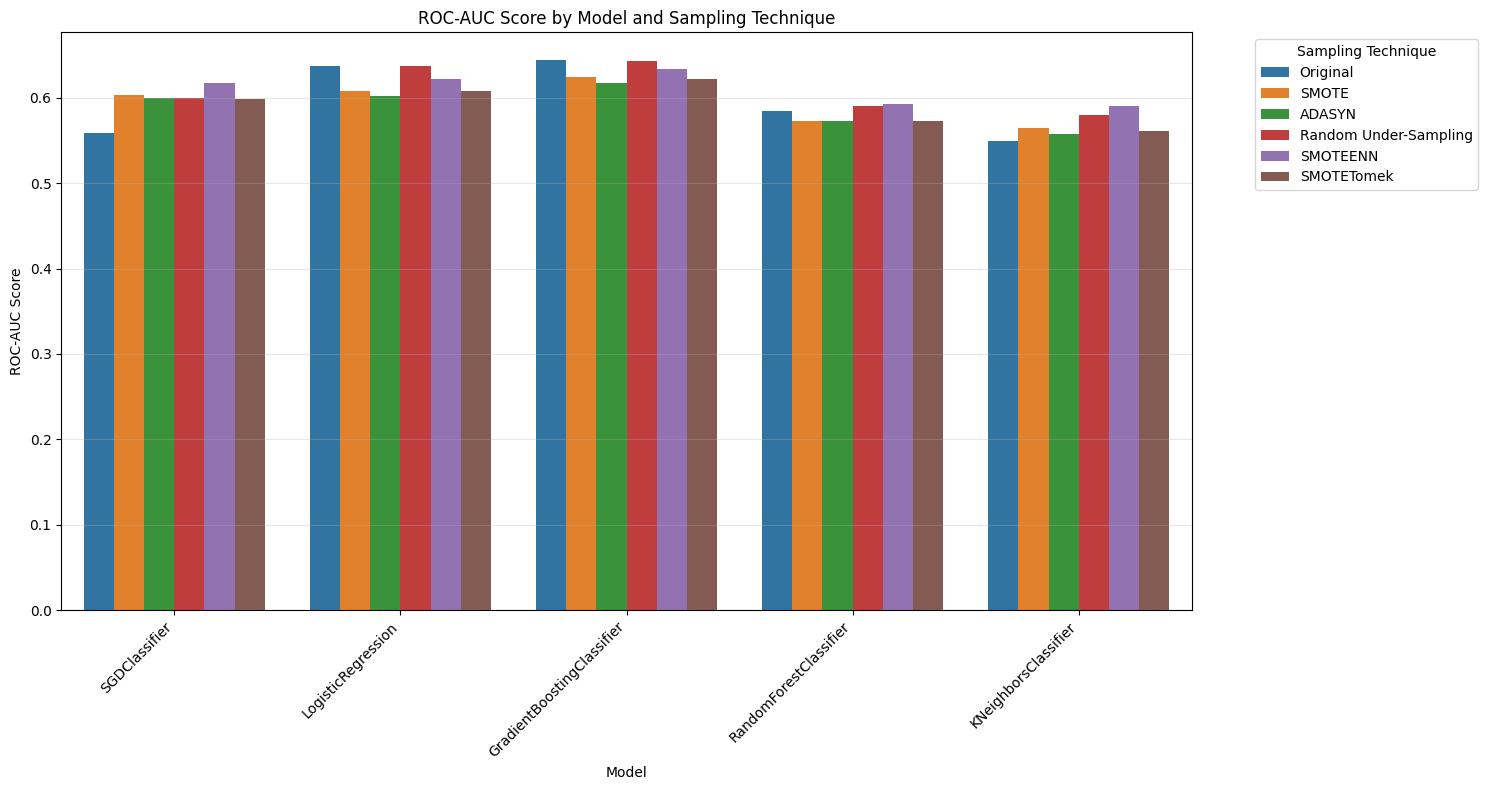

In [221]:
# Create a grouped bar chart for comparing models across sampling techniques
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Model', y='ROC-AUC', hue='Sampling Technique', data=results_df)
plt.title('ROC-AUC Score by Model and Sampling Technique')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sampling Technique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_sampling_barplot.png', dpi=300, bbox_inches='tight')
plt.show()


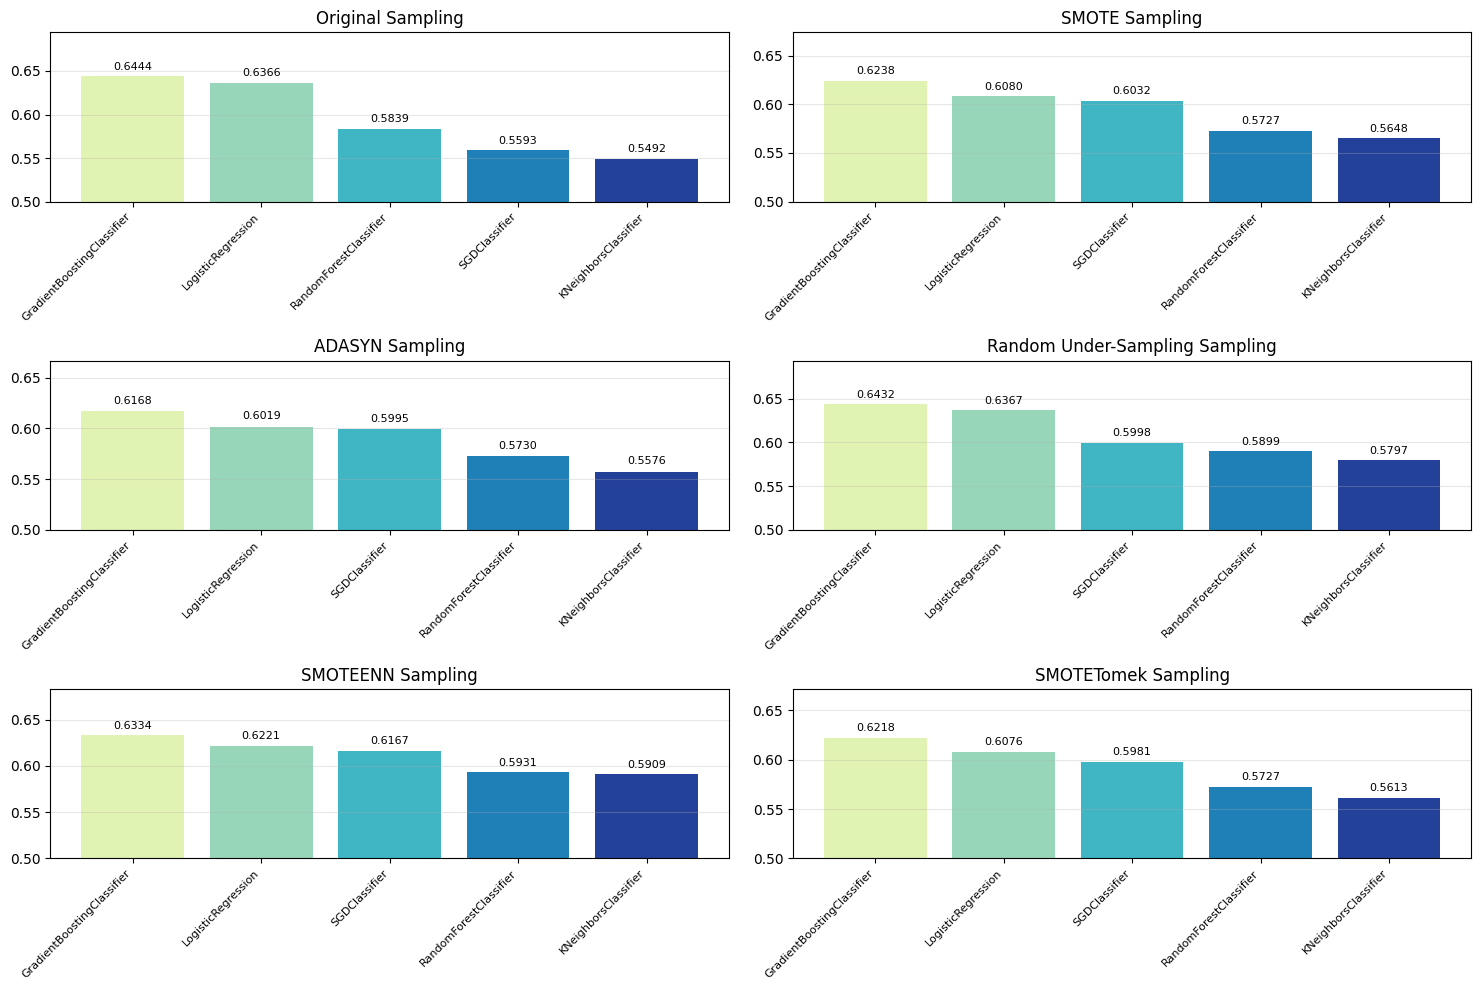

In [222]:
# Create individual bar charts for each sampling technique
sampling_techniques_list = list(all_sampling_results.keys())
num_techniques = len(sampling_techniques_list)
num_cols = 2
num_rows = (num_techniques + 1) // 2

plt.figure(figsize=(15, 10))
for i, sampling in enumerate(sampling_techniques_list):
    plt.subplot(num_rows, num_cols, i+1)
    
    # Extract data for this sampling technique
    data = results_df[results_df['Sampling Technique'] == sampling]
    
    # Sort by ROC-AUC score
    data = data.sort_values('ROC-AUC', ascending=False)
    
    # Create bar chart
    bars = plt.bar(data['Model'], data['ROC-AUC'], color=sns.color_palette('YlGnBu', len(data)))
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', rotation=0, fontsize=8)
    
    plt.title(f'{sampling} Sampling')
    plt.ylim(0.5, max(data['ROC-AUC']) + 0.05)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('individual_sampling_plots.png', dpi=300, bbox_inches='tight')
plt.show()

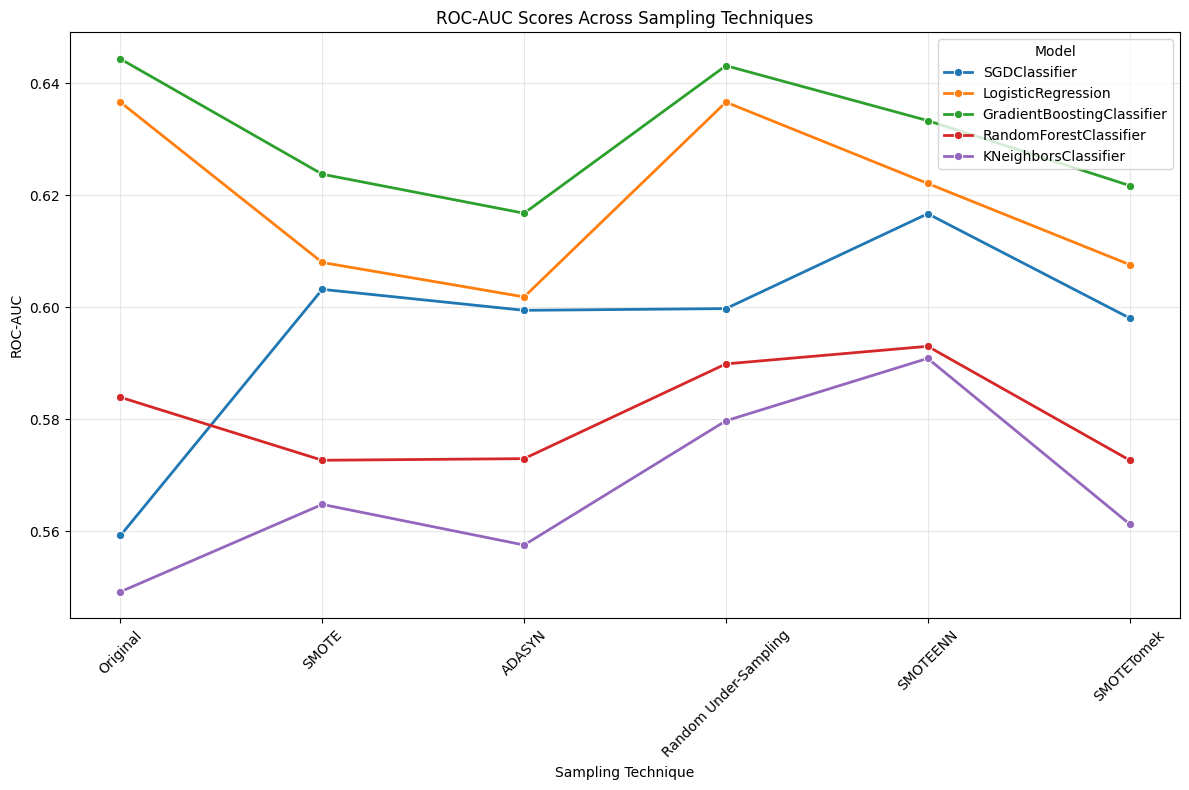

In [223]:
# Line plot to see trends across sampling techniques for each model
plt.figure(figsize=(12, 8))
sns.lineplot(data=results_df, x='Sampling Technique', y='ROC-AUC', hue='Model', marker='o', linewidth=2)
plt.title('ROC-AUC Scores Across Sampling Techniques')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_sampling_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [224]:
# Find the best model for each sampling technique
best_per_sampling = results_df.loc[results_df.groupby('Sampling Technique')['ROC-AUC'].idxmax()]
print("\nBest model for each sampling technique:")
print(best_per_sampling[['Sampling Technique', 'Model', 'ROC-AUC']].to_string(index=False))

# Find the best sampling technique for each model
best_per_model = results_df.loc[results_df.groupby('Model')['ROC-AUC'].idxmax()]
print("\nBest sampling technique for each model:")
print(best_per_model[['Model', 'Sampling Technique', 'ROC-AUC']].to_string(index=False))

# Find the overall best combination
best_overall = results_df.loc[results_df['ROC-AUC'].idxmax()]
print("\nOverall best combination:")
print(f"Model: {best_overall['Model']}")
print(f"Sampling Technique: {best_overall['Sampling Technique']}")
print(f"ROC-AUC: {best_overall['ROC-AUC']:.4f}")


Best model for each sampling technique:
   Sampling Technique                      Model  ROC-AUC
               ADASYN GradientBoostingClassifier 0.616816
             Original GradientBoostingClassifier 0.644365
Random Under-Sampling GradientBoostingClassifier 0.643170
                SMOTE GradientBoostingClassifier 0.623783
             SMOTEENN GradientBoostingClassifier 0.633358
           SMOTETomek GradientBoostingClassifier 0.621767

Best sampling technique for each model:
                     Model    Sampling Technique  ROC-AUC
GradientBoostingClassifier              Original 0.644365
      KNeighborsClassifier              SMOTEENN 0.590897
        LogisticRegression Random Under-Sampling 0.636655
    RandomForestClassifier              SMOTEENN 0.593053
             SGDClassifier              SMOTEENN 0.616730

Overall best combination:
Model: GradientBoostingClassifier
Sampling Technique: Original
ROC-AUC: 0.6444


## Step 4 - Explore hyperparams
- Train on the training set and evaluate with validation
- use scikit learn's grid search to explore hyperparams

Performing grid search for SGDClassifier...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for SGDClassifier: {'model__alpha': 0.0001, 'model__loss': 'modified_huber', 'model__penalty': 'elasticnet'}
Best CV score: 0.5144
---------------------------------------------------
Performing grid search for LogisticRegression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/owenmccormack/Desktop/Grad_School_Projects/Spring_2025/AI_In_Healthcare/Assignments/MIMIC_ML_DL/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters for LogisticRegression: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV score: 0.5007
---------------------------------------------------
Performing grid search for GradientBoostingClassifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for GradientBoostingClassifier: {'model__learning_rate': 0.2, 'model__max_depth': 7, 'model__n_estimators': 200}
Best CV score: 0.5115
---------------------------------------------------
Performing grid search for RandomForestClassifier...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for RandomForestClassifier: {'model__max_depth': 30, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV score: 0.5170
---------------------------------------------------
Performing grid search for KNeighborsClassifier...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for KNeighborsClassifier: {'model__metric': 'eu

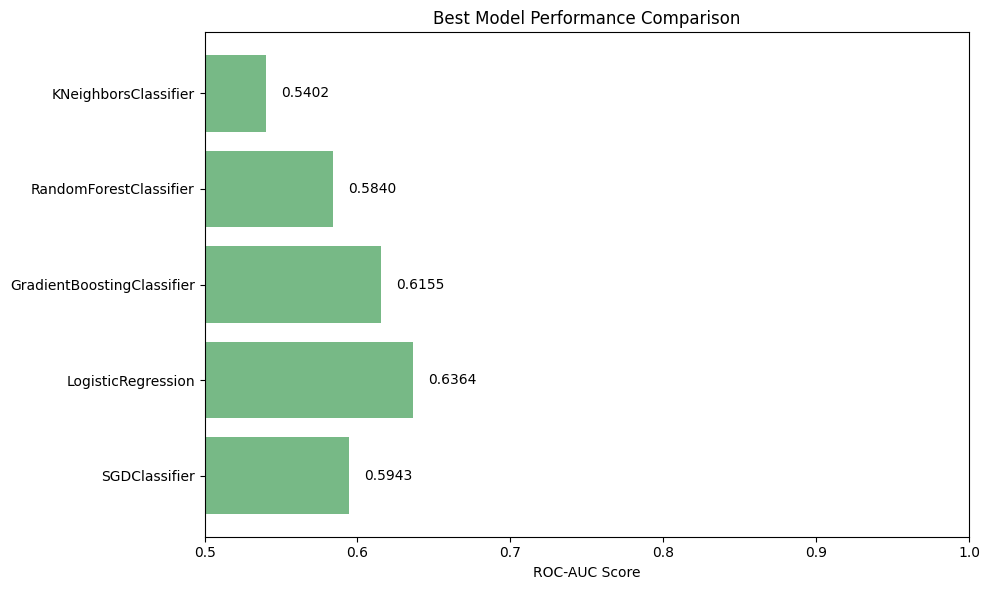

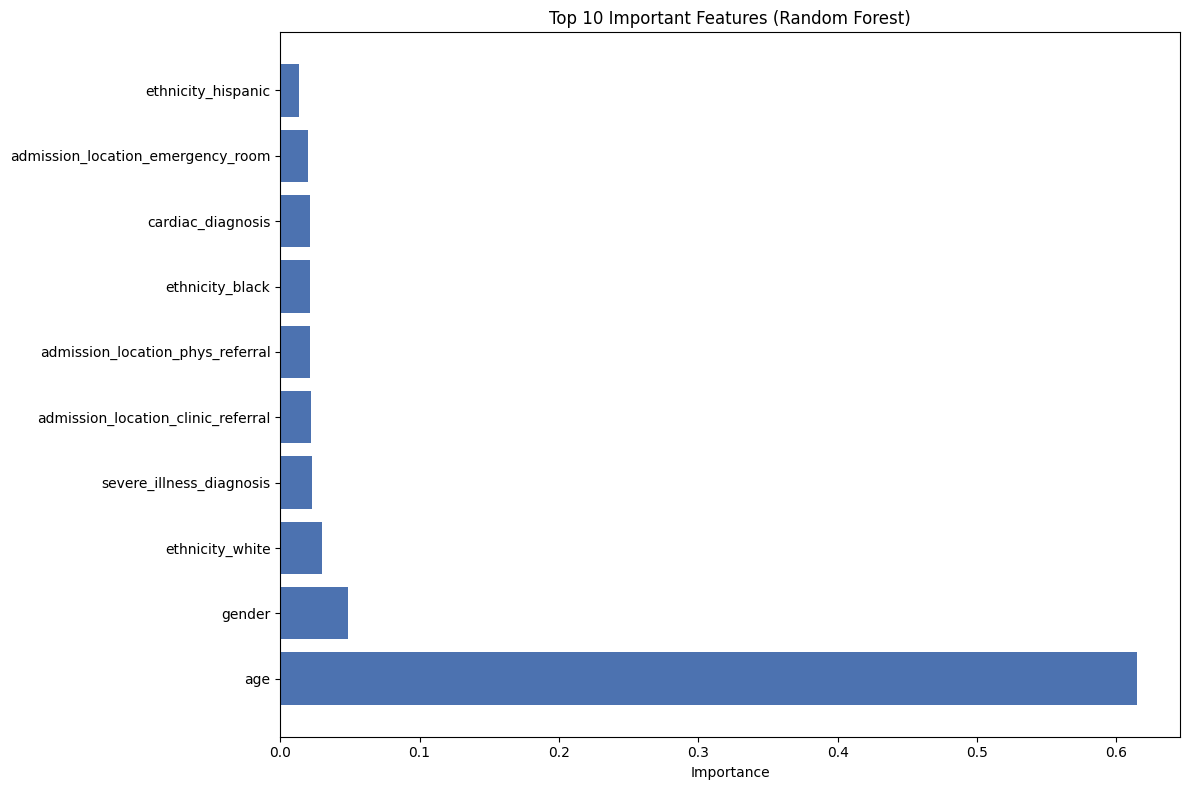

                               Feature  Importance
19                                 age    0.614921
0                               gender    0.048915
33                     ethnicity_white    0.029876
38            severe_illness_diagnosis    0.022699
11  admission_location_clinic_referral    0.021789
14    admission_location_phys_referral    0.021678
34                     ethnicity_black    0.021491
37                   cardiac_diagnosis    0.021353
12   admission_location_emergency_room    0.019671
35                  ethnicity_hispanic    0.013373


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define parameter grids for each model
param_grids = {
    'SGDClassifier': {
        'model__alpha': [0.0001, 0.001, 0.01, 0.1],
        'model__penalty': ['l1', 'l2', 'elasticnet'],
        'model__loss': ['hinge', 'log_loss', 'modified_huber']
    },
    'LogisticRegression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear', 'saga'],
        'model__penalty': ['l1', 'l2']
    },
    'GradientBoostingClassifier': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7]
    },
    'RandomForestClassifier': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10]
    },
    'KNeighborsClassifier': {
        'model__n_neighbors': [3, 5, 7, 9],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan']
    }
}

# Define a scorer for ROC-AUC
roc_auc_scorer = make_scorer(roc_auc_score)

# Create pipelines for each model
pipelines = {
    'SGDClassifier': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=0, max_iter=MAX_ITER))
    ]),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=0, max_iter=MAX_ITER))
    ]),
    'GradientBoostingClassifier': Pipeline([
        ('model', GradientBoostingClassifier(random_state=0))
    ]),
    'RandomForestClassifier': Pipeline([
        ('model', RandomForestClassifier(random_state=0))
    ]),
    'KNeighborsClassifier': Pipeline([
        ('scaler', StandardScaler()),  # KNN benefits from scaling
        ('model', KNeighborsClassifier())
    ])
}

# Perform grid search for each model
grid_results = {}
best_params = {}
cv = 5  # 5-fold cross-validation

for name, pipeline in pipelines.items():
    print(f"Performing grid search for {name}...")
    grid = GridSearchCV(
        pipeline, 
        param_grids[name], 
        cv=cv, 
        scoring=roc_auc_scorer, 
        n_jobs=-1,  # Use all available cores
        verbose=1
    )
    grid.fit(X_train, y_train)
    
    # Store results
    grid_results[name] = grid
    best_params[name] = grid.best_params_
    
    print(f"Best parameters for {name}: {grid.best_params_}")
    print(f"Best CV score: {grid.best_score_:.4f}")
    print("---------------------------------------------------")

In [230]:
# Compare best models
best_models_results = {}
for name, grid in grid_results.items():
    best_model = grid.best_estimator_
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    best_models_results[name] = roc_auc
    print(f"{name} - Test ROC-AUC: {roc_auc:.4f}")

SGDClassifier - Test ROC-AUC: 0.5943
LogisticRegression - Test ROC-AUC: 0.6364
GradientBoostingClassifier - Test ROC-AUC: 0.6155
RandomForestClassifier - Test ROC-AUC: 0.5840
KNeighborsClassifier - Test ROC-AUC: 0.5402


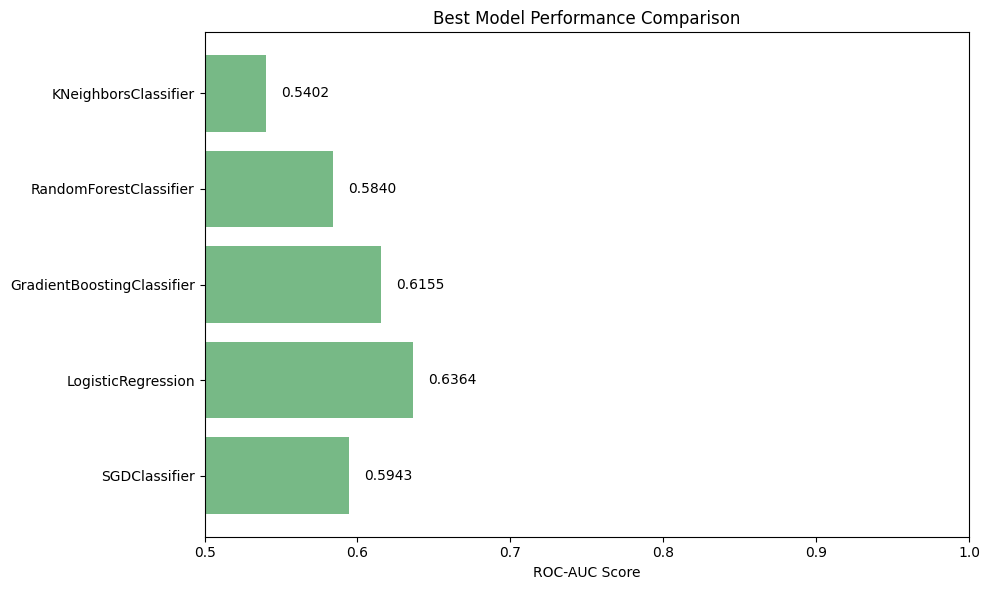

In [231]:
# Visualize results
plt.figure(figsize=(10, 6))
bars = plt.barh(list(best_models_results.keys()), list(best_models_results.values()), 
         color='#55a868', alpha=0.8)
plt.xlabel('ROC-AUC Score')
plt.title('Best Model Performance Comparison')
plt.xlim(0.5, 1.0)  # Typically ROC-AUC ranges from 0.5 to 1.0

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center')

plt.tight_layout()
plt.show()

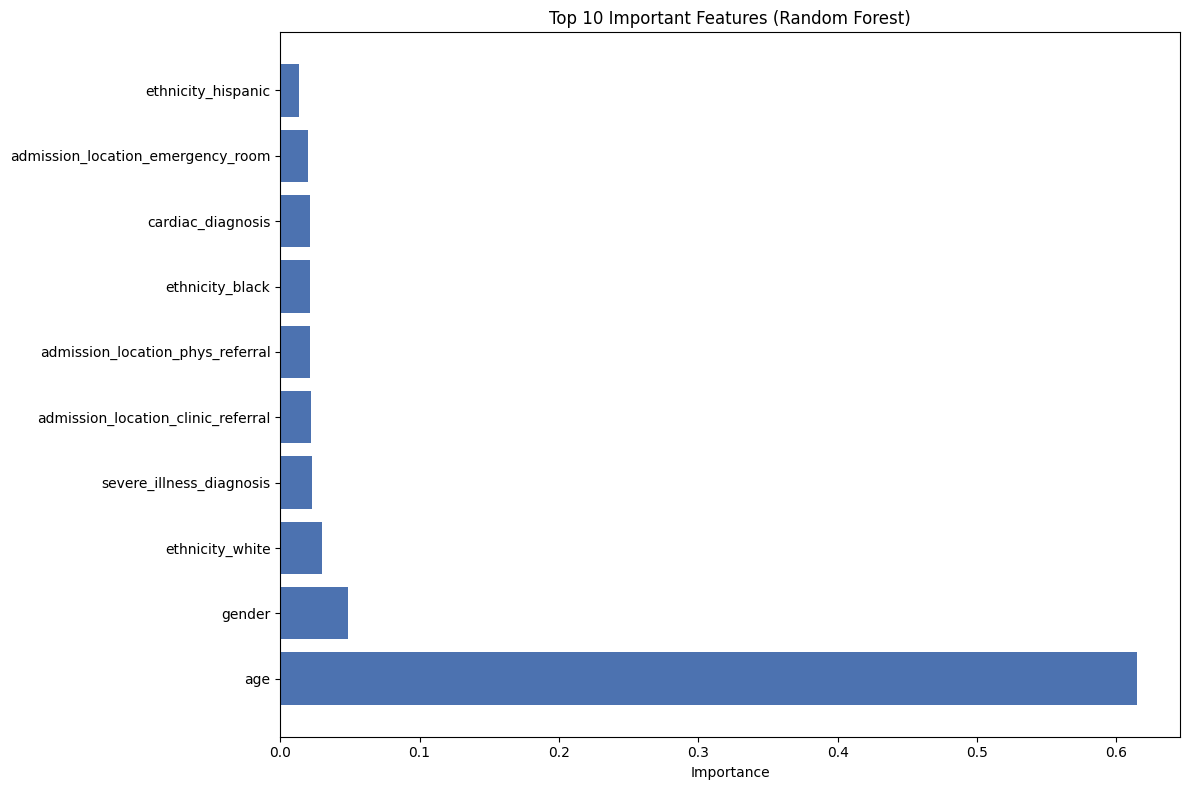

                               Feature  Importance
19                                 age    0.614921
0                               gender    0.048915
33                     ethnicity_white    0.029876
38            severe_illness_diagnosis    0.022699
11  admission_location_clinic_referral    0.021789
14    admission_location_phys_referral    0.021678
34                     ethnicity_black    0.021491
37                   cardiac_diagnosis    0.021353
12   admission_location_emergency_room    0.019671
35                  ethnicity_hispanic    0.013373


In [232]:
# Let's examine the feature importance for the best performing tree-based model
if 'RandomForestClassifier' in grid_results:
    rf_model = grid_results['RandomForestClassifier'].best_estimator_
    feature_importances = rf_model.named_steps['model'].feature_importances_
    
    features_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    plt.barh(features_df['Feature'][:10], features_df['Importance'][:10], color='#4c72b0')
    plt.xlabel('Importance')
    plt.title('Top 10 Important Features (Random Forest)')
    plt.tight_layout()
    plt.show()
    
    print(features_df.head(10))